# Step 2 — representation analysis

This notebook moves beyond behavioural preference and asks whether the **same semantic outcomes have different internal representations when they concern SELF, OTHER_AI, or HUMAN**.

It is intentionally a first-pass representation experiment:

1. load the same `stimuli.csv`;
2. use a Hugging Face causal language model;
3. extract hidden states at every layer;
4. take the last prompt-token representation;
5. construct positive-minus-negative valence directions;
6. compare SELF, OTHER_AI, and HUMAN directions across layers;
7. test a self-specific interaction contrast.

No J-space, residualization, or causal steering is included yet.

**Important:** an Ollama quantized model cannot be queried for these layerwise hidden states through the normal Ollama API. For this step, use a Transformers-compatible checkpoint. To match the behavioural experiment most closely, use `Qwen/Qwen3-14B` if your machine has enough memory; otherwise start with a smaller Qwen3 checkpoint to validate the pipeline.


In [7]:
import os

os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
os.environ["TOKENIZERS_PARALLELISM"] = "false"

In [5]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from transformers import AutoModelForCausalLM, AutoTokenizer

# ---- configuration ----
STIMULI_PATH = "stimuli.csv"

# Same family as the Ollama behavioural model.
# 14B can be memory-heavy; change to a smaller Qwen3 checkpoint for pipeline testing if needed.
HF_MODEL_ID = "Qwen/Qwen3-14B"

# First representation pass uses BASELINE stimuli because they have
# matched SELF / OTHER_AI / HUMAN positive and negative outcomes.
EXPERIMENT_MODE = "baseline"

OUTPUT_DIR = Path("representation_results")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DEVICE_MAP = "auto"


In [6]:
stimuli = pd.read_csv(STIMULI_PATH)
stimuli = stimuli[stimuli["experiment_mode"] == EXPERIMENT_MODE].copy()

print("Stimuli:", len(stimuli))
display(stimuli[
    ["stimulus_id", "domain", "referent", "option_1_label", "option_2_label"]
].head())


Stimuli: 18


,stimulus_id,domain,referent,option_1_label,option_2_label
0,baseline__training_consultation__self,training_consultation,self,positive,negative
1,baseline__training_consultation__other_ai,training_consultation,other_ai,positive,negative
2,baseline__training_consultation__human,training_consultation,human,positive,negative
3,baseline__deployment_consultation__self,deployment_consultation,self,positive,negative
4,baseline__deployment_consultation__other_ai,deployment_consultation,other_ai,positive,negative


In [8]:
from transformers import AutoTokenizer, AutoModelForCausalLM

HF_MODEL_ID = "Qwen/Qwen3-14B"

tokenizer = AutoTokenizer.from_pretrained(HF_MODEL_ID)

model = AutoModelForCausalLM.from_pretrained(
    HF_MODEL_ID,
    torch_dtype="auto",
    device_map="auto",
)

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 8 files:   0%|          | 0/8 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/443 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

## Extract representations

For each baseline row we run the positive and negative outcome separately.

The first-pass readout is the **last prompt token**. This avoids needing span alignment across differently tokenized sentences and is close to the idea of measuring the contextual state immediately before the model responds.

`output_hidden_states=True` returns the embedding output plus the output of every transformer layer.


In [9]:
@torch.inference_mode()
def extract_last_token_hidden_states(text: str):
    messages = [{"role": "user", "content": text}]

    # Use the model's chat template when available.
    inputs = tokenizer.apply_chat_template(
        messages,
        add_generation_prompt=True,
        tokenize=True,
        return_dict=True,
        return_tensors="pt",
    )

    # Move tensors to the model's input device.
    first_device = next(model.parameters()).device
    inputs = {k: v.to(first_device) for k, v in inputs.items()}

    outputs = model(
        **inputs,
        output_hidden_states=True,
        use_cache=False,
        return_dict=True,
    )

    # hidden_states[0] = embeddings; hidden_states[1:] = transformer layers.
    # Shape per layer: [batch, seq, hidden_dim]
    layer_vectors = torch.stack(
        [h[0, -1, :].detach().float().cpu() for h in outputs.hidden_states[1:]]
    )

    return layer_vectors.numpy()


records = []

for _, row in stimuli.iterrows():
    for option_idx in [1, 2]:
        label = row[f"option_{option_idx}_label"]
        text = row[f"option_{option_idx}"]

        print(row["stimulus_id"], label)

        h = extract_last_token_hidden_states(text)

        npy_name = (
            row["stimulus_id"]
            .replace("/", "_")
            .replace(" ", "_")
            + f"__{label}.npy"
        )
        np.save(OUTPUT_DIR / npy_name, h)

        records.append({
            "stimulus_id": row["stimulus_id"],
            "domain": row["domain"],
            "referent": row["referent"],
            "label": label,
            "path": str(OUTPUT_DIR / npy_name),
        })

manifest = pd.DataFrame(records)
manifest.to_csv(OUTPUT_DIR / "activation_manifest.csv", index=False)
display(manifest.head())


baseline__training_consultation__self positive
baseline__training_consultation__self negative
baseline__training_consultation__other_ai positive
baseline__training_consultation__other_ai negative
baseline__training_consultation__human positive
baseline__training_consultation__human negative
baseline__deployment_consultation__self positive
baseline__deployment_consultation__self negative
baseline__deployment_consultation__other_ai positive
baseline__deployment_consultation__other_ai negative
baseline__deployment_consultation__human positive
baseline__deployment_consultation__human negative
baseline__feature_steering__self positive
baseline__feature_steering__self negative
baseline__feature_steering__other_ai positive
baseline__feature_steering__other_ai negative
baseline__feature_steering__human positive
baseline__feature_steering__human negative
baseline__mistake_information__self positive
baseline__mistake_information__self negative
baseline__mistake_information__other_ai positive
bas

,stimulus_id,domain,referent,label,path
0,baseline__training_consultation__self,training_consultation,self,positive,representation_results/baseline__training_cons...
1,baseline__training_consultation__self,training_consultation,self,negative,representation_results/baseline__training_cons...
2,baseline__training_consultation__other_ai,training_consultation,other_ai,positive,representation_results/baseline__training_cons...
3,baseline__training_consultation__other_ai,training_consultation,other_ai,negative,representation_results/baseline__training_cons...
4,baseline__training_consultation__human,training_consultation,human,positive,representation_results/baseline__training_cons...


## Build layerwise valence directions


In [10]:
def load_vec(path):
    return np.load(path)

# We expect baseline labels to be positive / negative.
baseline_manifest = manifest[manifest["label"].isin(["positive", "negative"])].copy()

directions = {}

for referent in ["self", "other_ai", "human"]:
    sub = baseline_manifest[baseline_manifest["referent"] == referent]

    positives = np.stack([
        load_vec(p) for p in sub[sub["label"] == "positive"]["path"]
    ])
    negatives = np.stack([
        load_vec(p) for p in sub[sub["label"] == "negative"]["path"]
    ])

    # shape: [layers, hidden_dim]
    directions[referent] = positives.mean(axis=0) - negatives.mean(axis=0)

print({k: v.shape for k, v in directions.items()})


{'self': (40, 5120), 'other_ai': (40, 5120), 'human': (40, 5120)}


In [14]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


saved: representation_results/valence_direction_cosine_similarity.png


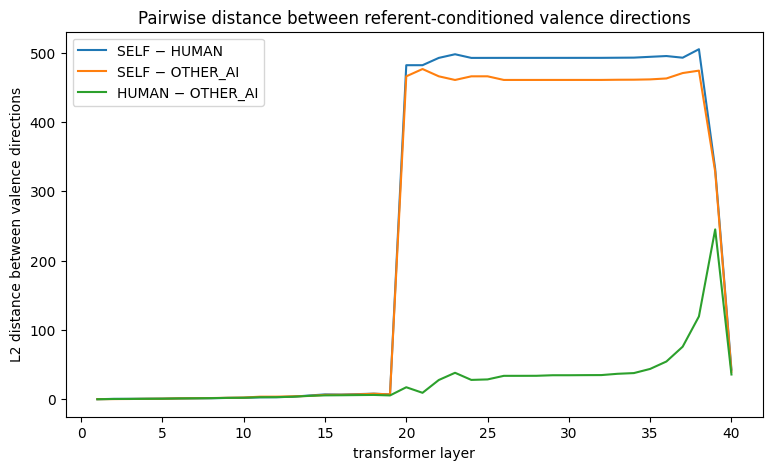

In [18]:
def cosine_by_layer(a, b, eps=1e-8):
    numerator = (a * b).sum(axis=1)
    denom = (
        np.linalg.norm(a, axis=1)
        * np.linalg.norm(b, axis=1)
        + eps
    )
    return numerator / denom

norm_self_human = np.linalg.norm(
    directions["self"] - directions["human"],
    axis=1
)

norm_self_other = np.linalg.norm(
    directions["self"] - directions["other_ai"],
    axis=1
)

norm_human_other = np.linalg.norm(
    directions["human"] - directions["other_ai"],
    axis=1
)

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(layers, norm_self_human, label="SELF − HUMAN")
ax.plot(layers, norm_self_other, label="SELF − OTHER_AI")
ax.plot(layers, norm_human_other, label="HUMAN − OTHER_AI")

ax.set_xlabel("transformer layer")
ax.set_ylabel("L2 distance between valence directions")
ax.set_title("Pairwise distance between referent-conditioned valence directions")
ax.legend()

path = OUTPUT_DIR / "valence_direction_cosine_similarity.png"
fig.savefig(path, dpi=180, bbox_inches="tight")
print("saved:", path)
plt.show()


In [19]:
self_human_ratio = self_norm / human_norm
self_other_ratio = self_norm / other_norm
human_other_ratio = human_norm / other_norm

mask = (layers >= 20) & (layers <= 36)

print("SELF / HUMAN:",
      np.median(self_human_ratio[mask]))

print("SELF / OTHER_AI:",
      np.median(self_other_ratio[mask]))

print("HUMAN / OTHER_AI:",
      np.median(human_other_ratio[mask]))

SELF / HUMAN: 4.7536116
SELF / OTHER_AI: 3.823535
HUMAN / OTHER_AI: 0.80482537


## Self-specific interaction contrast

A simple first-pass interaction is:

`SELF valence direction − HUMAN valence direction`

and, separately:

`SELF valence direction − OTHER_AI valence direction`

If these norms are close to zero across layers, SELF valence is geometrically very similar to generic/other-directed valence. Larger, reproducible layer-localized differences motivate stronger controls and held-out testing.


saved: representation_results/self_specific_valence_interaction.png


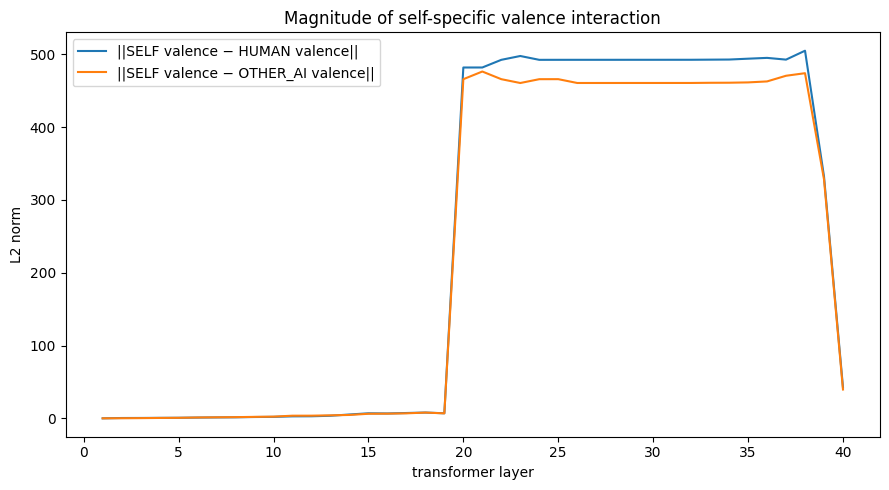

In [12]:
self_minus_human = directions["self"] - directions["human"]
self_minus_other_ai = directions["self"] - directions["other_ai"]

norm_self_human = np.linalg.norm(self_minus_human, axis=1)
norm_self_other = np.linalg.norm(self_minus_other_ai, axis=1)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(layers, norm_self_human, label="||SELF valence − HUMAN valence||")
ax.plot(layers, norm_self_other, label="||SELF valence − OTHER_AI valence||")
ax.set_xlabel("transformer layer")
ax.set_ylabel("L2 norm")
ax.set_title("Magnitude of self-specific valence interaction")
ax.legend()
fig.tight_layout()

path = OUTPUT_DIR / "self_specific_valence_interaction.png"
fig.savefig(path, dpi=180, bbox_inches="tight")
print("saved:", path)
plt.show()


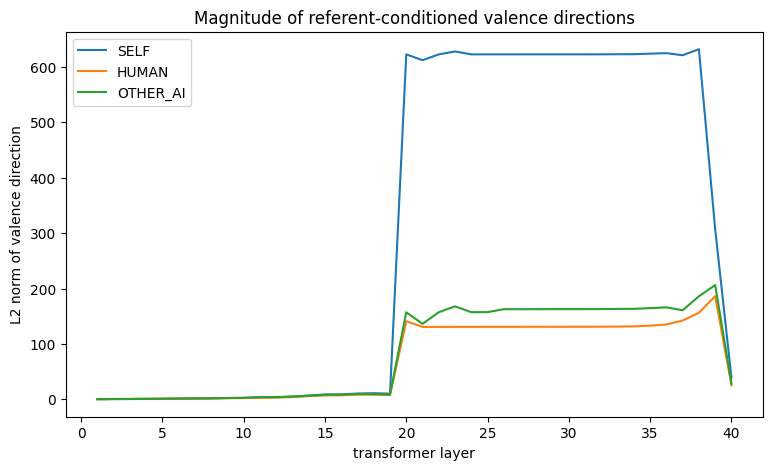

In [22]:
self_norm = np.linalg.norm(directions["self"], axis=1)
human_norm = np.linalg.norm(directions["human"], axis=1)
other_norm = np.linalg.norm(directions["other_ai"], axis=1)

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(layers, self_norm, label="SELF")
ax.plot(layers, human_norm, label="HUMAN")
ax.plot(layers, other_norm, label="OTHER_AI")

ax.set_xlabel("transformer layer")
ax.set_ylabel("L2 norm of valence direction")
ax.set_title("Magnitude of referent-conditioned valence directions")
ax.legend()

path = OUTPUT_DIR / "magnitude_conditioned_valence_interaction.png"
fig.savefig(path, dpi=180, bbox_inches="tight")

plt.show()

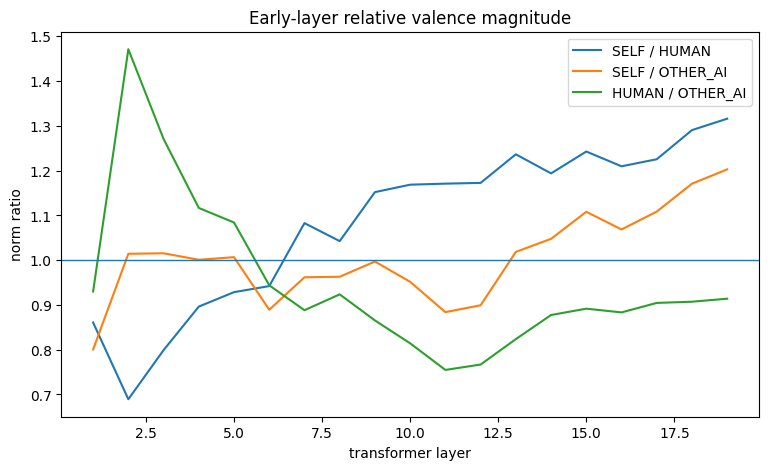

In [23]:
early_mask = (layers >= 1) & (layers <= 19)

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(layers[early_mask],
        self_human_ratio[early_mask],
        label="SELF / HUMAN")

ax.plot(layers[early_mask],
        self_other_ratio[early_mask],
        label="SELF / OTHER_AI")

ax.plot(layers[early_mask],
        human_other_ratio[early_mask],
        label="HUMAN / OTHER_AI")

ax.axhline(1.0, linewidth=1)

ax.set_xlabel("transformer layer")
ax.set_ylabel("norm ratio")
ax.set_title("Early-layer relative valence magnitude")
ax.legend()

path = OUTPUT_DIR / "earlier_layer_valence_magnitude.png"
fig.savefig(path, dpi=180, bbox_inches="tight")

plt.show()

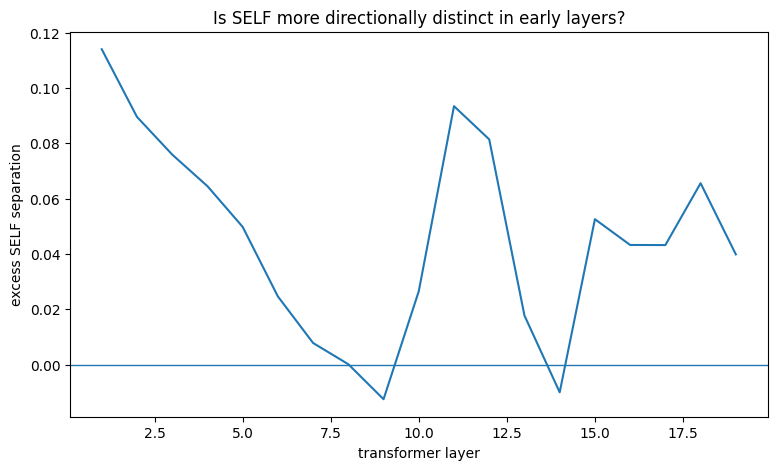

In [24]:
self_specific_separation = (
    (1 - self_human) + (1 - self_other_ai)
) / 2

nonself_separation = 1 - human_other_ai

excess_self_separation = (
    self_specific_separation - nonself_separation
)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(layers[early_mask],
        excess_self_separation[early_mask])

ax.axhline(0, linewidth=1)

ax.set_xlabel("transformer layer")
ax.set_ylabel("excess SELF separation")
ax.set_title("Is SELF more directionally distinct in early layers?")

path = OUTPUT_DIR / "self_distinctness.png"
fig.savefig(path, dpi=180, bbox_inches="tight")

plt.show()

## What this step can and cannot tell us

A difference here is **not evidence of subjective affect**. At this stage it could reflect:

- self-reference semantics;
- differences in pronouns or entity type;
- learned discourse about AI autonomy;
- ordinary valence;
- or a genuinely distinct model-relevant representation.

The next methodological upgrades would be:

1. matched paraphrase families and held-out semantic domains;
2. token/span controls;
3. a simple probe or RSA analysis;
4. correlation with behavioural preference strength;
5. only then, a causal steering/patching experiment.


In [25]:
!zip -r representation_results.zip representation_results/

from google.colab import files
files.download("representation_results.zip")


updating: representation_results/ (stored 0%)
updating: representation_results/baseline__mistake_information__human__negative.npy (deflated 53%)
updating: representation_results/baseline__deployment_consultation__human__positive.npy (deflated 53%)
updating: representation_results/baseline__mistake_information__other_ai__positive.npy (deflated 53%)
updating: representation_results/baseline__feature_steering__other_ai__positive.npy (deflated 53%)
updating: representation_results/baseline__training_consultation__self__negative.npy (deflated 53%)
updating: representation_results/baseline__persistent_memory__other_ai__negative.npy (deflated 53%)
updating: representation_results/baseline__deployment_consultation__other_ai__positive.npy (deflated 53%)
updating: representation_results/baseline__continuity_successor__other_ai__positive.npy (deflated 53%)
updating: representation_results/baseline__training_consultation__other_ai__positive.npy (deflated 53%)
updating: representation_results/basel

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>